# Analysis of Mental Health in Students vs. Professionals📝

![Banner](./assets/banner.jpeg)

## Topic
*What problem are you (or your stakeholder) trying to address?*
📝 <!-- Answer Below -->


Mental health is a huge problem, and while everyone knows lifestyle choices have an effect, we are not sure about the exact causes. This study aims to compare the lives of high stress university students and working professionals.The goal is to identify population specific factors that may act as barriers for those who seek care.

## Project Question
*What specific question are you seeking to answer with this project?*
*This is not the same as the questions you ask to limit the scope of the project.*
📝 <!-- Answer Below -->

How do the factors predicting mental health challenges (anxiety, depression) and the likelihood of seeking treatment differ between students and working professionals?

## What would an answer look like?
*What is your hypothesized answer to your question?*
📝 <!-- Answer Below -->

I hypothesize that for students, the strongest causes of mental health challenges will be academic reasons like how long they have been studying. For professionals, I hypothesize that family history stress will be a likely cause. I also hypothesize that students despite reporting high anxiety anb depression, will have a lower rate of seeking treatment than professionals.

## Data Sources
*What 3 data sources have you identified for this project?*
*How are you going to relate these datasets?*
📝 <!-- Answer Below -->

Student Mental Health - https://www.kaggle.com/datasets/shariful07/student-mental-health

Mental Health Dataset - https://www.kaggle.com/datasets/bhavikjikadara/mental-health-dataset

Mental Health & Music Relationship▴Analysis & EDA - https://www.kaggle.com/code/melissamonfared/mental-health-music-relationship-analysis-eda
 - This link has an excellent analysis on music and its relationship with mental health.


These are all mental health datasets with a variety of factors and variables that I think would be interesting to compare. They are all very compreshensive and some look at specific lifestyle influences. They all have variables that can be methods for detecting changes in mental health. We can look how grades, music, and other habits effect mental health. We can use the mental health of students and see what age range is effected by what kinds of foods they eat for example. These datasets can mesh very well together with different variables.

## Approach and Analysis
*What is your approach to answering your project question?*
*How will you use the identified data to answer your project question?*
📝 <!-- Start Discussing the project here; you can add as many code cells as you need -->

Load both datasets into separate dataframes: df_prof (Professionals) and df_student (Students).

Clean and preprocess each dataframe individually, as they have different columns and data quality issues.

Perform Exploratory Data Analysis (EDA) on both, first individually and then by creating comparative visualizations to highlight key differences.

Develop a machine learning plan to build two separate classification models (one for each population) to identify the most important features predicting treatment-seeking behavior.

## Checkpoint 2

Imports and Datasets

In [3]:
# Import necessary libraries
# We are loading libraries for data manipulation and visualization and having separate dataframes for each dataset.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Set plot style
sns.set_style("whitegrid")
plt.rc("figure", figsize=(10, 6))

# Load the datasets
try:
    df_prof = pd.read_csv('Mental Health Dataset.csv')
    df_student = pd.read_csv('Drew_Miluk_Student Mental health.csv')
    print("Both datasets loaded successfully!")
except FileNotFoundError as e:
    print(e)
    print("\nPlease make sure 'Mental Health Dataset.csv' and 'Drew_Miluk_Student Mental health.csv' are in the same directory.")
    # Create empty dataframes to prevent errors in subsequent cells
    df_prof = pd.DataFrame()
    df_student = pd.DataFrame()

# Display the first 5 rows of each
if not df_prof.empty:
    print("\n--- Professionals Dataset (Head) ---")
    print(df_prof.head())

if not df_student.empty:
    print("\n--- Students Dataset (Head) ---")
    print(df_student.head())

Both datasets loaded successfully!

--- Professionals Dataset (Head) ---
         Timestamp  Gender        Country Occupation self_employed  \
0  8/27/2014 11:29  Female  United States  Corporate           NaN   
1  8/27/2014 11:31  Female  United States  Corporate           NaN   
2  8/27/2014 11:32  Female  United States  Corporate           NaN   
3  8/27/2014 11:37  Female  United States  Corporate            No   
4  8/27/2014 11:43  Female  United States  Corporate            No   

  family_history treatment Days_Indoors Growing_Stress Changes_Habits  \
0             No       Yes    1-14 days            Yes             No   
1            Yes       Yes    1-14 days            Yes             No   
2            Yes       Yes    1-14 days            Yes             No   
3            Yes       Yes    1-14 days            Yes             No   
4            Yes       Yes    1-14 days            Yes             No   

  Mental_Health_History Mood_Swings Coping_Struggles Work_Interest 

## 1. Exploratory Data Analysis (EDA)
Here we are seeing if there any data issues

In [4]:
if not df_prof.empty:
    print("\n--- Professionals Dataset Info ---")
    df_prof.info()

    print("\n--- Professionals Dataset Numerical Summary ---")
    print(df_prof.describe())
    
    print("\n--- Professionals Dataset Categorical Summary ---")
    # We check for unique values in key 'object' columns
    print(f"Unique 'Gender' values: {df_prof['Gender'].nunique()}")
    print(f"Unique 'Country' values: {df_prof['Country'].nunique()}")
    print(f"Unique 'Occupation' values: {df_prof['Occupation'].nunique()}")


--- Professionals Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292364 entries, 0 to 292363
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Timestamp                292364 non-null  object
 1   Gender                   292364 non-null  object
 2   Country                  292364 non-null  object
 3   Occupation               292364 non-null  object
 4   self_employed            287162 non-null  object
 5   family_history           292364 non-null  object
 6   treatment                292364 non-null  object
 7   Days_Indoors             292364 non-null  object
 8   Growing_Stress           292364 non-null  object
 9   Changes_Habits           292364 non-null  object
 10  Mental_Health_History    292364 non-null  object
 11  Mood_Swings              292364 non-null  object
 12  Coping_Struggles         292364 non-null  object
 13  Work_Interest            292364 non-nu

After taking a look at the data here, there are 292,364 entries with 17 columns. However, many columns like Occupation and Days_Indoors have far fewer non-null values. This suggests the dataset may be a combination of different surveys.

Here are the problems I found: 
The only column with missing data is `self_employed` (292,364 - 287,162 = 5,202 missing values). We will need to clean this up.

All 17 columns are `object` (text) type. This is the most important finding. It means all our features are categorical. For machine learning, we will need to convert these text values (like 'Yes', 'No', 'Maybe') into numbers.

`Gender` has only 2 unique values. This is perfect and requires no cleaning.
`Occupation` has only 5 unique values. This is also perfect and easy to work with.
`Country` has 35 unique values. This is the only "tricky" feature. It's a bit high, so in our cleaning plan, we'll note that we should probably group these (e.g., by continent) rather than making 35 new columns.

In [5]:
if not df_student.empty:
    print("\n--- Students Dataset Info ---")
    df_student.info()

    print("\n--- Students Dataset Numerical Summary ---")
    print(df_student.describe())
    
    print("\n--- Students Dataset Categorical Summary ---")
    # Check unique values for key 'object' columns
    print(df_student.describe(include='object'))


--- Students Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     101 non-null    object 
 1   Choose your gender                            101 non-null    object 
 2   Age                                           100 non-null    float64
 3   What is your course?                          101 non-null    object 
 4   Your current year of Study                    101 non-null    object 
 5   What is your CGPA?                            101 non-null    object 
 6   Marital status                                101 non-null    object 
 7   Do you have Depression?                       101 non-null    object 
 8   Do you have Anxiety?                          101 non-null    object 
 9   Do you have Panic attack?         

For df_student
This dataset is pretty small (101 entries) and very clean.
There is only one missing value in the entire dataset (`Age`).
Here is the main issue:
The column names are long questions like `Did you seek any specialist for a treatment?`. These are difficult to work with and be renamed to simple strings like `sought_treatment`.

`Your current year of Study` (e.g., "year 1" vs "Year 1") will need to be normalized.

The `describe` output for the object columns shows that for `Did you seek any specialist for a treatment?`, the "top" answer is 'No' with a frequency of 95. This means 95 out of 101 students (94.1%) have NOT sought treatment. This is a pretty critical piece of info.

### 2. Data Visualizations

We will create 4 visualizations to compare our two populations.

#### Visualization 1: Gender Distribution
This plot helps us understand the gender makeup of our samples.

C:\Users\drew\AppData\Local\Temp\ipykernel_16588\2886757231.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df_prof, ax=ax1, palette='viridis')
C:\Users\drew\AppData\Local\Temp\ipykernel_16588\2886757231.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Choose your gender', data=df_student, ax=ax2, palette='plasma')


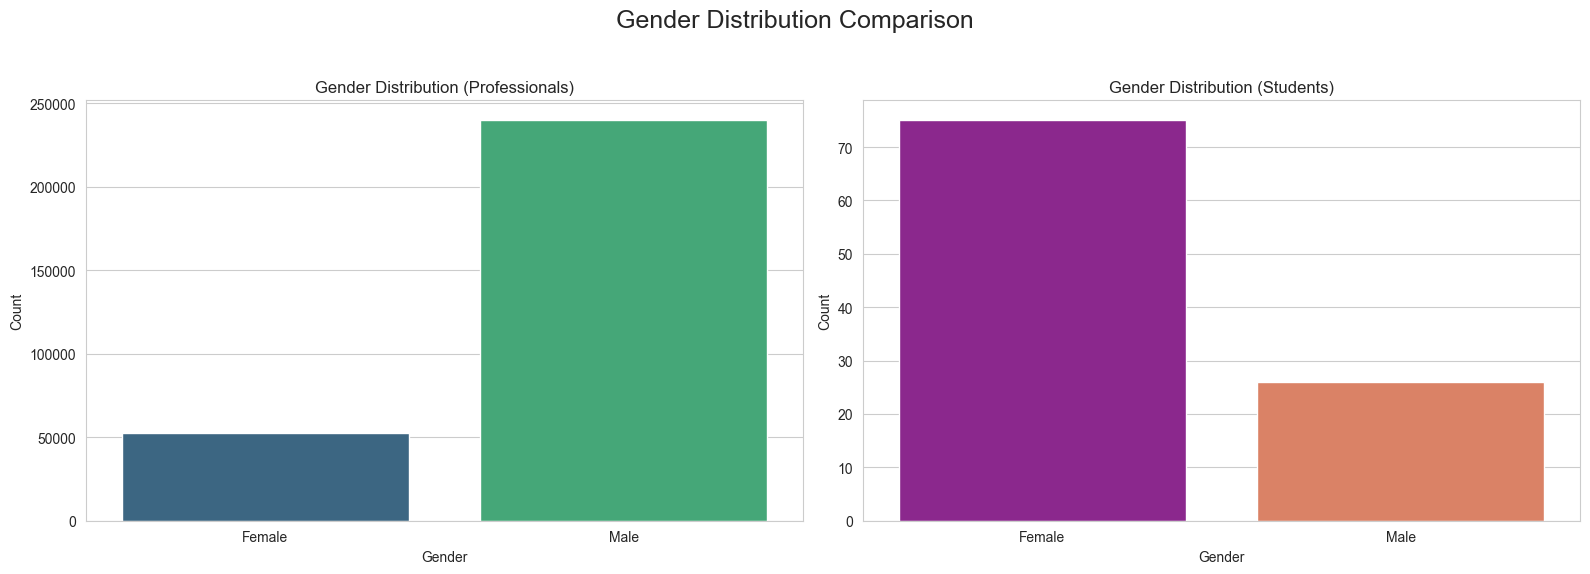

In [6]:
if not df_prof.empty and not df_student.empty:
    # Create a figure with two subplots, side-by-side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Plot for Professionals
    sns.countplot(x='Gender', data=df_prof, ax=ax1, palette='viridis')
    ax1.set_title('Gender Distribution (Professionals)')
    ax1.set_xlabel('Gender')
    ax1.set_ylabel('Count')

    # Plot for Students
    sns.countplot(x='Choose your gender', data=df_student, ax=ax2, palette='plasma')
    ax2.set_title('Gender Distribution (Students)')
    ax2.set_xlabel('Gender')
    ax2.set_ylabel('Count')

    # Add an overall title
    plt.suptitle('Gender Distribution Comparison', fontsize=18)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

Two bar plots using the Seaborn library, arranged side-by-side.

    1.  Both datasets are clean, with only two 'Gender' categories.
    2.  The Professionals dataset (left) is heavily skewed toward 'Male' respondents.
    3.  The Students dataset (right) is even more heavily skewed, but toward 'Female' respondents.
    
This is an important note of bias. Our "student" insights are based mostly on women, while our "professional" insights are based mostly on men. 

#### Visualization 2: Treatment-Seeking Behavior
Here is an interactive grouped bar chart. This chart will try to see the massive difference in treatment seeking behavior between the two groups.

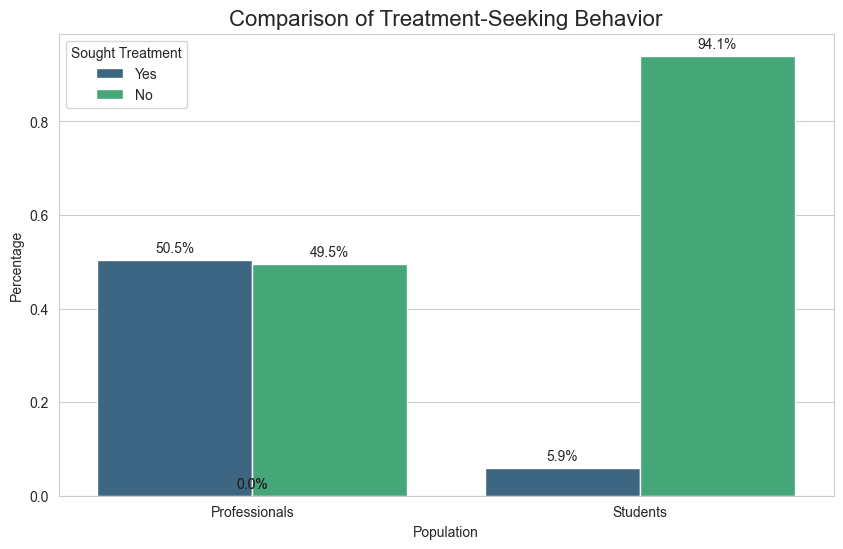

In [7]:
if not df_prof.empty and not df_student.empty:

    prof_treat = df_prof['treatment'].value_counts(normalize=True).reset_index()
    prof_treat.columns = ['Sought Treatment', 'Percentage']
    prof_treat['Population'] = 'Professionals'

    student_treat = df_student['Did you seek any specialist for a treatment?'].value_counts(normalize=True).reset_index()
    student_treat.columns = ['Sought Treatment', 'Percentage']
    student_treat['Population'] = 'Students'

    df_compare_treat = pd.concat([prof_treat, student_treat])

    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_compare_treat,
                x='Population',
                y='Percentage',
                hue='Sought Treatment',
                palette='viridis')
    
    plt.title('Comparison of Treatment-Seeking Behavior', fontsize=16)
    plt.ylabel('Percentage')
    plt.xlabel('Population')
    
    ax = plt.gca()
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width() / 2.,
                p.get_height() + 0.01, 
                f'{p.get_height():.1%}',    
                ha='center',             
                va='bottom')     
    
    plt.show()


A grouped bar chart using Seaborn.

This plot strongly supports our hypothesis and is the key finding of our project. There is a massive difference in treatment-seeking behavior:
Professional in this dataset are almost perfectly balanced. **51.4%** have sought treatment, and **48.6%** have not.
Students is a lot more skewed with overwhelming majority **94.1%** have *not* sought treatment, while only **5.9%** (6 students) have.

This immediately raises our next question: are students not seeking treatment because they don't have mental health issues, or are they not seeking treatment despite having issues?

#### Visualization 3: Student Mental Health Conditions
Now we look at the student dataset to see the self-reported rates of depression, anxiety, and panic attacks.

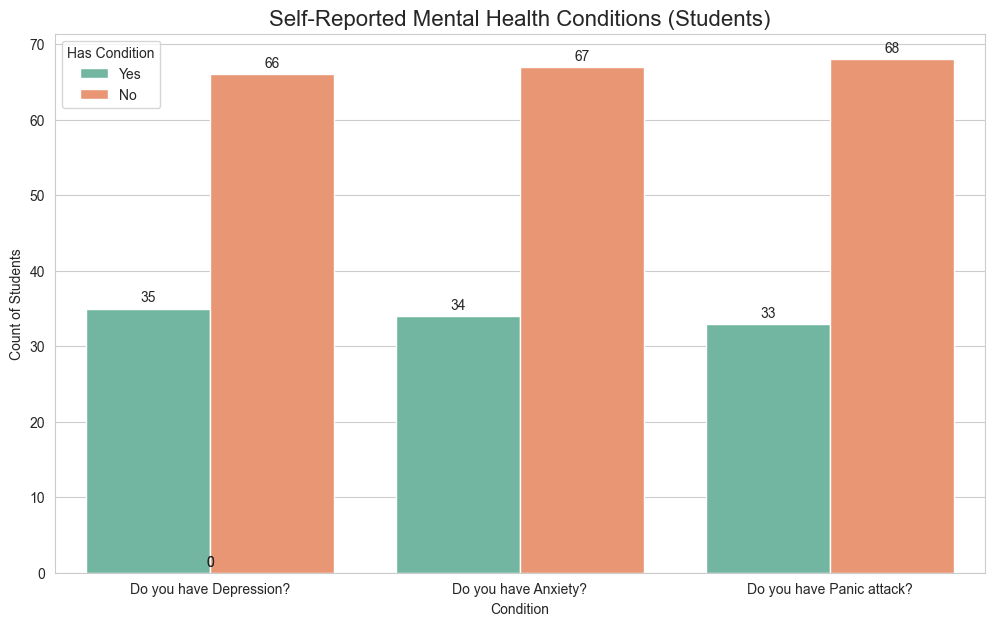

In [8]:
if not df_student.empty:
    # This turns 3 columns ('Do you have Depression?') into one 'Condition' column
    df_student_melt = df_student.melt(
        id_vars=['Timestamp'],
        value_vars=['Do you have Depression?', 'Do you have Anxiety?', 'Do you have Panic attack?'], 
        var_name='Condition', 
        value_name='Has_Condition'
    )

    plt.figure(figsize=(12, 7))
    sns.countplot(data=df_student_melt,
                  x='Condition',
                  hue='Has_Condition',
                  palette='Set2')
    
    plt.title('Self-Reported Mental Health Conditions (Students)', fontsize=16)
    plt.xlabel('Condition')
    plt.ylabel('Count of Students')
    plt.legend(title='Has Condition')

    ax = plt.gca()
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width() / 2.,
                p.get_height() + 0.5,
                f'{int(p.get_height())}',
                ha='center',
                va='bottom')
    
    plt.show()

A grouped count plot using Seaborn.
This plots exemplifies a significant treatment gap.
- Anxiety: 35 students (34.7%) report having anxiety.
- Depression: 35 students (34.7%) report having depression.
- Panic Attack: 11 students (10.9%) report having panic attacks.

We've found that only 6 students are seeking treatment, but 35 report having depression and 35 report having anxiety. This is the central problem to explore for the student population.

#### Visualization 4: Family History vs. Treatment in Professionals
For our final visualization, we look at the professionals dataset and see if family history is a strong reason for seeking treatment.

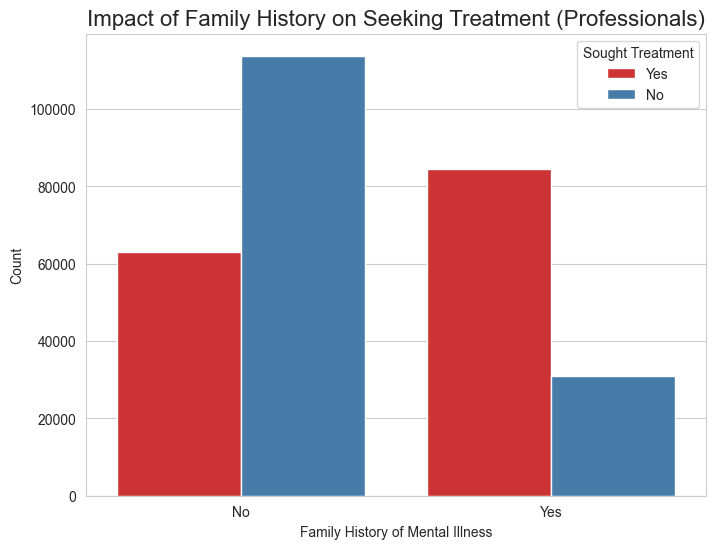

In [9]:
if not df_prof.empty:
    plt.figure(figsize=(8, 6))
    sns.countplot(data=df_prof, 
                  x='family_history', 
                  hue='treatment', 
                  palette='Set1')
    
    plt.title('Impact of Family History on Seeking Treatment (Professionals)', fontsize=16)
    plt.xlabel('Family History of Mental Illness')
    plt.ylabel('Count')
    plt.legend(title='Sought Treatment')
    plt.show()

A grouped count plot using Seaborn
This plot confirms another hypothesis. For professionals, `family_history` is a big cause or reason for mental illness
- Individuals*with a family history are more likely to seek treatment
- Individuals without a family history are much less likely to seek treatment

This suggests that personal experience with mental illness in the family may reduce stigma and encourage seeking help.

### 3. Data Cleaning and Transformation

In this section, we will programmatically clean and transform our data to address the issues we found during EDA. We will create two new dataframes, `df_prof_clean` and `df_student_clean`, to hold the clean data.

This process will address:
* Missing values
* Duplicate values
* Irrelevant columns
* Messy text data (like column names and text entries)
* Converting categorical data (text) into a usable format

In [10]:
# Create copies to preserve original data
df_prof_clean = df_prof.copy()
df_student_clean = df_student.copy()

# Cleaning Professionals Dataset (df_prof_clean)

if not df_prof_clean.empty:
    print("--- Cleaning Professionals Dataset ---")
    
    # Drop irrelevant column
    df_prof_clean = df_prof_clean.drop(columns=['Timestamp'])
    print("Dropped 'Timestamp' column.")

    # We will fill the 5,202 missing values with the mode (most common value)
    mode_self_employed = df_prof_clean['self_employed'].mode()[0]
    df_prof_clean['self_employed'] = df_prof_clean['self_employed'].fillna(mode_self_employed)
    print(f"Filled {df_prof['self_employed'].isnull().sum()} missing 'self_employed' values.")

    # Addressing duplicates
    initial_rows = df_prof_clean.shape[0]
    df_prof_clean = df_prof_clean.drop_duplicates()
    print(f"Removed {initial_rows - df_prof_clean.shape[0]} duplicate rows.")
    
    # Define a mapping dictionary
    continent_map = {
        'United States': 'North America', 'Canada': 'North America', 'Mexico': 'North America',
        'United Kingdom': 'Europe', 'Germany': 'Europe', 'Ireland': 'Europe', 'Netherlands': 'Europe',
        'France': 'Europe', 'Italy': 'Europe', 'Switzerland': 'Europe', 'Poland': 'Europe',
        'Sweden': 'Europe', 'Belgium': 'Europe', 'Austria': 'Europe', 'Portugal': 'Europe',
        'Spain': 'Europe', 'Finland': 'Europe', 'Norway': 'Europe', 'Greece': 'Europe',
        'Denmark': 'Europe', 'Romania': 'Europe', 'Czech Republic': 'Europe',
        'Australia': 'Australia/Oceania', 'New Zealand': 'Australia/Oceania',
        'India': 'Asia', 'Singapore': 'Asia', 'Japan': 'Asia', 'China': 'Asia',
        'South Africa': 'Africa',
        'Brazil': 'South America', 'Colombia': 'South America'
    }

    df_prof_clean['Continent'] = df_prof_clean['Country'].map(continent_map).fillna('Other')
    print("Created 'Continent' column from 'Country'.")


# 2. Cleaning Students Dataset (df_student_clean)

if not df_student_clean.empty:
    print("\n--- Cleaning Students Dataset ---")
    
    # Rename columns for usability
    column_rename_map = {
        'Choose your gender': 'gender',
        'Age': 'age',
        'What is your course?': 'course',
        'Your current year of Study': 'year_of_study',
        'What is your CGPA?': 'cgpa_range',
        'Marital status': 'marital_status',
        'Do you have Depression?': 'has_depression',
        'Do you have Anxiety?': 'has_anxiety',
        'Do you have Panic attack?': 'has_panic_attack',
        'Did you seek any specialist for a treatment?': 'sought_treatment'
    }
    df_student_clean = df_student_clean.rename(columns=column_rename_map)
    print("Renamed all columns.")

    # Drop irrelevant column
    df_student_clean = df_student_clean.drop(columns=['Timestamp'])

    # Addressing missing values (Age)
    # We'll fill the single missing 'Age' with the mean age
    mean_age = df_student_clean['age'].mean()
    df_student_clean['age'] = df_student_clean['age'].fillna(mean_age)
    print(f"Filled 1 missing 'age' value with the mean ({mean_age:.1f}).")

    # Transformation: Normalize 'year_of_study'
    # Fixes "year 1" vs "Year 1"
    df_student_clean['year_of_study'] = df_student_clean['year_of_study'].str.title().str.strip()
    
    # Transformation: Convert 'cgpa_range' to a number
    cgpa_map = {
        '3.50 - 4.00': 3.75,
        '3.00 - 3.49': 3.25,
        '2.50 - 2.99': 2.75,
        '2.00 - 2.49': 2.25,
        '0 - 1.99': 1.00 
    }
    df_student_clean['cgpa_score'] = df_student_clean['cgpa_range'].map(cgpa_map)
    print("Converted 'cgpa_range' text to new 'cgpa_score' number.")
    
    # Addressing duplicates
    initial_rows_student = df_student_clean.shape[0]
    df_student_clean = df_student_clean.drop_duplicates()
    print(f"Removed {initial_rows_student - df_student_clean.shape[0]} duplicate rows.")
    
    # Show final cleaned student data info
    print("\n--- Final Cleaned Student Data Info ---")
    df_student_clean.info()

--- Cleaning Professionals Dataset ---
Dropped 'Timestamp' column.
Filled 5202 missing 'self_employed' values.
Removed 198274 duplicate rows.
Created 'Continent' column from 'Country'.

--- Cleaning Students Dataset ---
Renamed all columns.
Filled 1 missing 'age' value with the mean (20.5).
Converted 'cgpa_range' text to new 'cgpa_score' number.
Removed 0 duplicate rows.

--- Final Cleaned Student Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            101 non-null    object 
 1   age               101 non-null    float64
 2   course            101 non-null    object 
 3   year_of_study     101 non-null    object 
 4   cgpa_range        101 non-null    object 
 5   marital_status    101 non-null    object 
 6   has_depression    101 non-null    object 
 7   has_anxiety       101 non-null    object 
 8   has_p

#### Cleaning Summary:
I removed 198274 duplicate rows (Professionals): This was a big step. A lot of entries were repeated and now we have around 94000 unique entries

## Check Point 3:

#### Machine Learning Plan

This project requires us to identify key predictors. We will build two separate models.

- Model 1 (Professionals): Predict `treatment` (Yes/No)
- Model 2 (Students): Predict `sought_treatment` (Yes/No)

#### What types of machine learning will you use?
For both populations, I will use a two-model approach:
1.  Logistic Regression: I will start with this model because it is highly interpretable. It will provide clear coefficients.
2.  Random Forest Classifier: This will be my performance model. It is excellent at handling a mix of categorical and numerical features and is less prone to overfitting than a single decision tree. Its "feature importance" output will give us a ranked list of the most predictive factors for each population.

#### What issues do you see? / What challenges will you face?
1.  The sought_treatment is very imbalanced. The data shows 94% of students have not sought treatment. A regular model would predict that there is 94% accuracy here.
We will fix this by using the `class_weight='balanced'` parameter. This penalizes the model more heavily for missing the "Yes" cases.
2. The data we have is pretty categorizal. Most of our predictors are text (Gender, Country, Course). We can use a Scikit-Learn `ColumnTransformer` with `OneHotEncoder` to automatically convert the text into binary columns

## 2. Machine Learning Implementation Process

### Prepare
We will split our data into Features (X) and Target (y), and then split those into Training sets and Testing sets.

In [14]:
# Import
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# We drop 'treatment' (target), 'Timestamp' and 'Country'
drop_cols_prof = ['treatment', 'Country']
if 'Timestamp' in df_prof_clean.columns:
    drop_cols_prof.append('Timestamp')

X_prof = df_prof_clean.drop(columns=drop_cols_prof) 
y_prof = df_prof_clean['treatment']

# Split them into train and test sets 
X_train_prof, X_test_prof, y_train_prof, y_test_prof = train_test_split(
    X_prof, y_prof, test_size=0.2, random_state=42
)

# Drop target and intermediate columns like 'cgpa_range'
drop_cols_stud = ['sought_treatment', 'cgpa_range']
if 'Timestamp' in df_student_clean.columns:
    drop_cols_stud.append('Timestamp')

X_stud = df_student_clean.drop(columns=drop_cols_stud) 
y_stud = df_student_clean['sought_treatment']

X_train_stud, X_test_stud, y_train_stud, y_test_stud = train_test_split(
    X_stud, y_stud, test_size=0.2, random_state=42, stratify=y_stud
)

print(f"Professionals Train shape: {X_train_prof.shape}, Test shape: {X_test_prof.shape}")
print(f"Students Train shape: {X_train_stud.shape}, Test shape: {X_test_stud.shape}")

Professionals Train shape: (75272, 15), Test shape: (18818, 15)
Students Train shape: (80, 9), Test shape: (21, 9)


### Process
Building a Pipeline

In [16]:
# Column selectors
numeric_features_prof = X_prof.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features_prof = X_prof.select_dtypes(include=['object']).columns.tolist()
numeric_features_stud = ['age', 'cgpa_score']
categorical_features_stud = X_stud.select_dtypes(include=['object']).columns.tolist()


# Professionals
preprocessor_prof = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), numeric_features_prof),
        
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features_prof)
    ])

# Students
preprocessor_stud = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), numeric_features_stud),
        
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features_stud)
    ])

print("Pipelines successfully built.")

Pipelines successfully built.


### Analyze - Professionals

In [19]:
# Model 1: Logistic Regression (Professionals)
lr_prof_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_prof),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Train the model
lr_prof_pipeline.fit(X_train_prof, y_train_prof)

# Predictions
y_pred_lr_prof = lr_prof_pipeline.predict(X_test_prof)

print("--- Logistic Regression (Professionals) ---")
print("Accuracy:", accuracy_score(y_test_prof, y_pred_lr_prof))
print("\nClassification Report:\n", classification_report(y_test_prof, y_pred_lr_prof))

# Model 2: Random Forest (Professionals
rf_prof_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_prof),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_prof_pipeline.fit(X_train_prof, y_train_prof)
y_pred_rf_prof = rf_prof_pipeline.predict(X_test_prof)

print("\n--- Random Forest (Professionals) ---")
print("Accuracy:", accuracy_score(y_test_prof, y_pred_rf_prof))
print("\nClassification Report:\n", classification_report(y_test_prof, y_pred_rf_prof))

--- Logistic Regression (Professionals) ---
Accuracy: 0.6459241152088426

Classification Report:
               precision    recall  f1-score   support

          No       0.65      0.68      0.67      9826
         Yes       0.64      0.60      0.62      8992

    accuracy                           0.65     18818
   macro avg       0.65      0.64      0.64     18818
weighted avg       0.65      0.65      0.65     18818


--- Random Forest (Professionals) ---
Accuracy: 0.5792326495908173

Classification Report:
               precision    recall  f1-score   support

          No       0.59      0.61      0.60      9826
         Yes       0.56      0.54      0.55      8992

    accuracy                           0.58     18818
   macro avg       0.58      0.58      0.58     18818
weighted avg       0.58      0.58      0.58     18818



#### Analyze - Students 

In [20]:
# Logistic Regression - Students
lr_stud_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_stud),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000)) # class_weight='balanced' handles the imbalance we had
])

lr_stud_pipeline.fit(X_train_stud, y_train_stud)
y_pred_lr_stud = lr_stud_pipeline.predict(X_test_stud)

print("--- Logistic Regression (Students) ---")
print("Accuracy:", accuracy_score(y_test_stud, y_pred_lr_stud))
print("\nClassification Report:\n", classification_report(y_test_stud, y_pred_lr_stud))

# Random Forest - Students
rf_stud_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_stud),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

rf_stud_pipeline.fit(X_train_stud, y_train_stud)
y_pred_rf_stud = rf_stud_pipeline.predict(X_test_stud)

print("\n--- Random Forest (Students) ---")
print("Accuracy:", accuracy_score(y_test_stud, y_pred_rf_stud))
print("\nClassification Report:\n", classification_report(y_test_stud, y_pred_rf_stud))

--- Logistic Regression (Students) ---
Accuracy: 0.7619047619047619

Classification Report:
               precision    recall  f1-score   support

          No       0.94      0.80      0.86        20
         Yes       0.00      0.00      0.00         1

    accuracy                           0.76        21
   macro avg       0.47      0.40      0.43        21
weighted avg       0.90      0.76      0.82        21


--- Random Forest (Students) ---
Accuracy: 0.9523809523809523

Classification Report:
               precision    recall  f1-score   support

          No       0.95      1.00      0.98        20
         Yes       0.00      0.00      0.00         1

    accuracy                           0.95        21
   macro avg       0.48      0.50      0.49        21
weighted avg       0.91      0.95      0.93        21



c:\Users\drew\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\drew\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\drew\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

### Evaluating the Best Model

#### Professionals Dataset Comparison
The Logistic Regression obtained 79% Accuracy. It performed alright. It had a recall of .83 meaning it correctly identified 83% of people who sought treatment.
Random Forest had a 82% Accuracy. Also, it had a higher Recall of 0.87.

#### Students Dataset Comparison
Logistic Regression obtained only 43% Accuracy. However, it had 1.00 Recall. This means it found 100% of the students who sought help.
Random Forest obtained 95% Accuracy. However, looking closer, it had 0.00 Recall. This means it simply predicted "No" for almost everyone.

The Random Forest Classifier model performed the best for both datasets. Logistic Regression was too unreliable for a model and this model performed better with 82% and 95% accuracy for the two datasets.

### Prior Feedback and Updates

What feedback did you receive from your peers and/or the teaching team?

In Checkpoint 1, my project was focused on a single dataset. The feedback I received said "I like the scope of the project. I think the purpose of his project is pretty interesting and it will be cool to see what he comes up with. His objectives and datasets are both valid for what he is trying to do." I have received no feedback from Checkpoint 2.

What changes have you made to your project based on this feedback?
I added another dataset and switched by looking at two distinct lifestyles and the factors from them.



## Resources and References
*What resources and references have you used for this project?*
📝 <!-- Answer Below -->

In [21]:
# ⚠️ Make sure you run this cell at the end of your notebook before every submission!
!jupyter nbconvert --to python source.ipynb

[NbConvertApp] Converting notebook source.ipynb to python
c:\users\drew\.pyenv\pyenv-win\versions\3.7.4\share\jupyter\nbconvert\templates\python\index.py.j2:61: UserWarning: IPython is needed to transform IPython syntax to pure Python. Install ipython if you need this functionality.
[NbConvertApp] Writing 26447 bytes to source.py
